# Preprocessing:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler,LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, SequentialFeatureSelector, RFE
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
df_train = pd.read_csv(filepath_or_buffer= r"../datasets/row_dataset/UNSW_NB15_training-set.csv")
df_test = pd.read_csv(filepath_or_buffer= r"../datasets/row_dataset/UNSW_NB15_testing-set.csv")

print(f"The shape of the training set: {df_train.shape}")
print(f"The shape of the testing set: {df_test.shape}")

df_train.drop(labels= ["id", "label"], axis= 1, inplace= True)
df_test.drop(labels= ["id", "label"], axis= 1, inplace= True)

print("-" * 50)
print(f"The shape of the training set: {df_train.shape}")
print(f"The shape of the testing set: {df_test.shape}")

The shape of the training set: (175341, 45)
The shape of the testing set: (82332, 45)
--------------------------------------------------
The shape of the training set: (175341, 43)
The shape of the testing set: (82332, 43)


In [3]:
print(f"The null values in the training dataset:\n{df_train.isna().sum()}")

The null values in the training dataset:
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports 

In [4]:
print(f"The null values in the testing dataset:\n{df_test.isna().sum()}")

The null values in the testing dataset:
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports  

In [5]:
print(f"The duplicated values in the training set: {df_train.duplicated().sum()}")
print(f"The duplicated values in the testing set: {df_test.duplicated().sum()}")

df_train.drop_duplicates(inplace= True)
df_test.drop_duplicates(inplace= True)

df_train.reset_index(drop= True, inplace= True)
df_test.reset_index(drop= True, inplace= True)

print(f"\ndropping duplicated values: \n")
print(f"The duplicated values in the training set: {df_train.duplicated().sum()}")
print(f"The duplicated values in the testing set: {df_test.duplicated().sum()}")

The duplicated values in the training set: 67601
The duplicated values in the testing set: 26387

dropping duplicated values: 

The duplicated values in the training set: 0
The duplicated values in the testing set: 0


In [6]:
y_train = df_train['attack_cat'].copy()
y_test = df_test['attack_cat'].copy()

X_train = df_train.copy()
X_train.drop(labels= 'attack_cat', axis= 1, inplace= True)

X_test = df_test.copy()
X_test.drop(labels= 'attack_cat', axis= 1, inplace= True)

column_num = X_train.select_dtypes(include= ['int64', 'float64']).columns.tolist()
column_obj = X_train.select_dtypes(include= 'object').columns.tolist()

print(f"The numerical features in the dataset: {len(column_num)}")
print(f"The categorical features in the dataset: {len(column_obj)}")
print("=" * 40)
print(f"The dimensionality of original set training: {df_train.shape}, testing: {df_test.shape}, id of training: {id(df_train)}")
print(f"The shape model feature training: {X_train.shape}, testing: {X_test.shape}, id of testing: {id(X_train)}")

The numerical features in the dataset: 39
The categorical features in the dataset: 3
The dimensionality of original set training: (107740, 43), testing: (55945, 43), id of training: 1941668851616
The shape model feature training: (107740, 42), testing: (55945, 42), id of testing: 1941671961456


In [7]:
label = LabelEncoder()

y_train_labeled = pd.Series(label.fit_transform(y_train), name= 'attack_cat', index= y_train.index)
y_test_labeled = pd.Series(label.transform(y_test), name= 'attack_cat', index=  y_test.index)

print(f"The new classes in the training target: {y_train_labeled.unique()}")
print(f"The new classes in the testing target: {y_test_labeled.unique()}")
print("Label mapping:", dict(zip(label.classes_, label.transform(label.classes_))))

The new classes in the training target: [6 1 0 4 8 7 3 2 9 5]
The new classes in the testing target: [6 7 1 2 3 0 4 9 8 5]
Label mapping: {'Analysis': 0, 'Backdoor': 1, 'DoS': 2, 'Exploits': 3, 'Fuzzers': 4, 'Generic': 5, 'Normal': 6, 'Reconnaissance': 7, 'Shellcode': 8, 'Worms': 9}


In [8]:
pipeline_transformer = ColumnTransformer(
    transformers=[
        (
            'Categorical_transformer',
            OneHotEncoder(
                handle_unknown= 'ignore',
                sparse_output= False
            ),
            column_obj
        ),
        (
            'Numerical_transformer',
            MinMaxScaler(),
            column_num
        )
    ],
    remainder='drop',
    verbose_feature_names_out= False
)

X_train_preprocessed = pipeline_transformer.fit_transform(X_train)
X_train_preprocessed = pd.DataFrame(data= X_train_preprocessed, columns= pipeline_transformer.get_feature_names_out(), index= X_train.index)

X_test_preprocessed = pipeline_transformer.transform(X_test)
X_test_preprocessed = pd.DataFrame(data= X_test_preprocessed, columns= pipeline_transformer.get_feature_names_out(), index= X_test.index)

print(f"The shape of the preprocessed training set: {X_train_preprocessed.shape}")
print(f"The shape of the preprocessed testing set: {X_test_preprocessed.shape}")

The shape of the preprocessed training set: (107740, 194)
The shape of the preprocessed testing set: (55945, 194)


In [9]:
df_train_preprocessed = pd.concat([X_train_preprocessed, y_train_labeled], axis= 1)
df_test_preprocessed = pd.concat([X_test_preprocessed, y_test_labeled], axis= 1)

print(f"The shape of the organ train dataset: {df_train_preprocessed.shape}")
print('=' * 50)
print(f"The shape of the test organ dataset: {df_test_preprocessed.shape}")

df_train_preprocessed.to_csv(r'../datasets/preprocessed/UNSW_training_preprocessed.csv', index= False)
df_test_preprocessed.to_csv(r'../datasets/preprocessed/UNSW_testing_preprocessed.csv', index= False)

The shape of the organ train dataset: (107740, 195)
The shape of the test organ dataset: (55945, 195)


# Filtering method:

## Chi2 test:

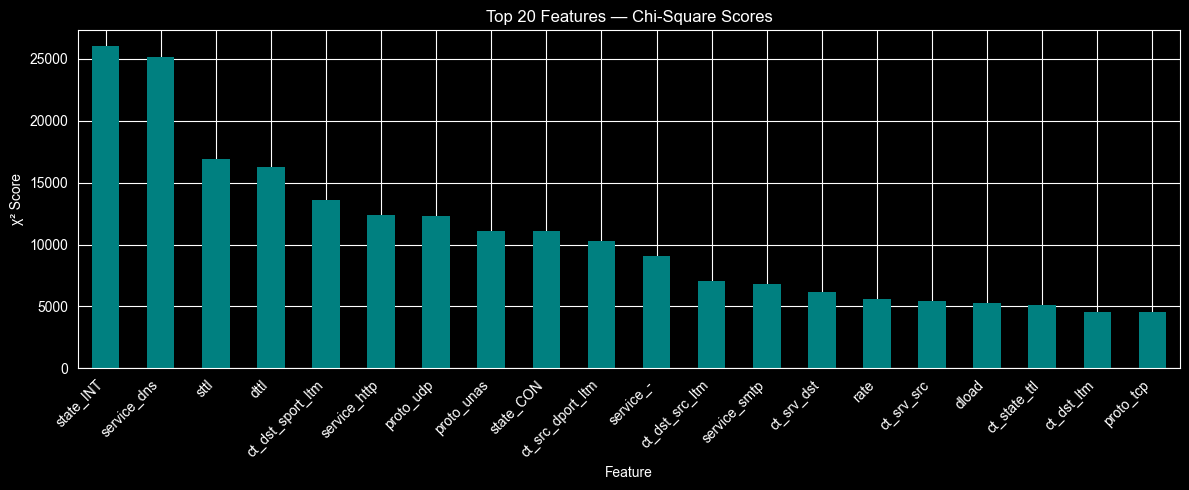

Top 20 features selected by Chi-Square test:
['state_INT', 'service_dns', 'sttl', 'dttl', 'ct_dst_sport_ltm', 'service_http', 'proto_udp', 'proto_unas', 'state_CON', 'ct_src_dport_ltm', 'service_-', 'ct_dst_src_ltm', 'service_smtp', 'ct_srv_dst', 'rate', 'ct_srv_src', 'dload', 'ct_state_ttl', 'ct_dst_ltm', 'proto_tcp']


In [10]:
k = 20
def select_k_best_test(data : pd.DataFrame, target : pd.Series, k_value : int = k, score_function : object = chi2, visualizing : bool = True) -> list:
    kbest_selector = SelectKBest(score_func= score_function, k = k_value) # type: ignore
    kbest_selector.fit(data, target)

    kbest_scores = pd.Series(kbest_selector.scores_, index= data.columns)
    kbest_scores_sorted = kbest_scores.sort_values(ascending= False)
    selected_features_kbest = kbest_scores_sorted.head(k_value).index.tolist()

    if visualizing:
        plt.figure(figsize= (12, 5))
        kbest_scores_sorted.head(k).plot(kind= 'bar', color= 'teal', edgecolor= 'none')
        plt.title(f'Top {k_value} Features — Chi-Square Scores')
        plt.xlabel('Feature')
        plt.ylabel('χ² Score')
        plt.xticks(rotation= 45, ha= 'right')
        plt.tight_layout()
        plt.show()

    return selected_features_kbest

chi2_selected_feature = select_k_best_test(data= X_train_preprocessed, target= y_train_labeled, k_value= k, score_function= chi2, visualizing= True)

print(f"Top {k} features selected by Chi-Square test:")
print(chi2_selected_feature)

## Mutual Info Selection:

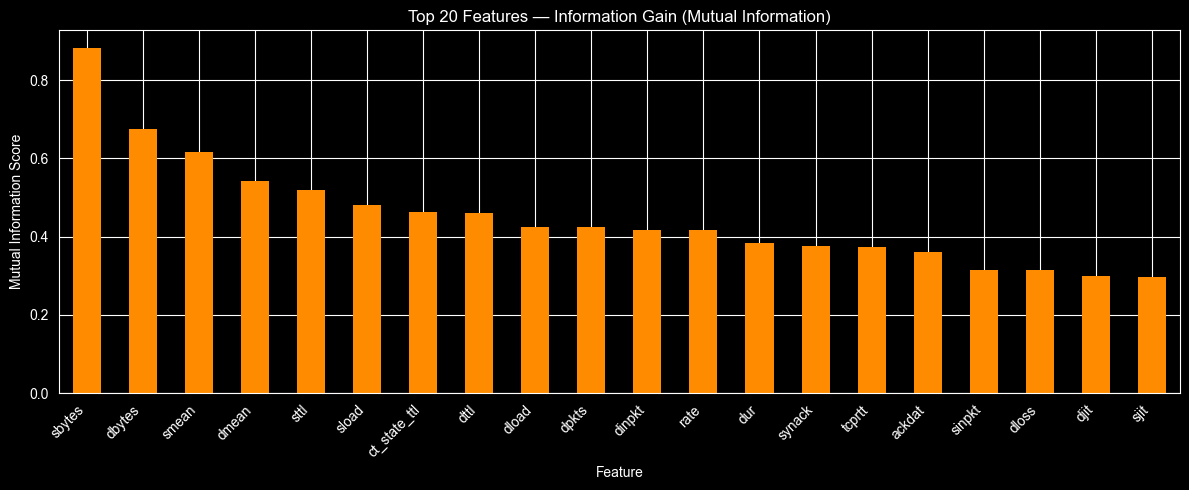

Top 20 features by Information Gain (Mutual Information):
['sbytes', 'dbytes', 'smean', 'dmean', 'sttl', 'sload', 'ct_state_ttl', 'dttl', 'dload', 'dpkts', 'dinpkt', 'rate', 'dur', 'synack', 'tcprtt', 'ackdat', 'sinpkt', 'dloss', 'djit', 'sjit']


In [11]:
def mutual_info_test(feature : pd.DataFrame, target : pd.Series, k_value : int = 10, visualizing : bool = True) -> list:

    mi_score = mutual_info_classif(feature, target, random_state= 42)
    mi_score = pd.Series(mi_score, index= feature.columns)
    mi_score = mi_score.sort_values(ascending= False)

    mi_top_features = mi_score.head(k_value).index.tolist()

    if visualizing:
        plt.figure(figsize= (12, 5))
        mi_score.head(k_value).plot(kind= 'bar', color= 'darkorange', edgecolor= 'none')
        plt.title(f'Top {k_value} Features — Information Gain (Mutual Information)')
        plt.xlabel('Feature')
        plt.ylabel('Mutual Information Score')
        plt.xticks(rotation= 45, ha= 'right')
        plt.tight_layout()
        plt.show()

    return mi_top_features

k_mi = 20
selected_features_mi = mutual_info_test(feature= X_train_preprocessed, target= y_train_labeled, k_value = k_mi, visualizing= True)

print(f"Top {k_mi} features by Information Gain (Mutual Information):")
print(selected_features_mi)

In [12]:
X_train_chi2 = X_train_preprocessed[chi2_selected_feature].copy()
X_train_mi = X_train_preprocessed[selected_features_mi].copy()

X_test_chi2 = X_test_preprocessed[chi2_selected_feature].copy()
X_test_mi = X_test_preprocessed[selected_features_mi].copy()

print(f"The shape of the train dataset after chi2: {X_train_chi2.shape}")
print(f"The shape of the train dataset after mutual info: {X_train_mi.shape}")
print('=' * 50)
print(f"The shape of the test dataset after chi2: {X_test_chi2.shape}")
print(f"The shape of the test dataset after mutual info: {X_test_mi.shape}")

The shape of the train dataset after chi2: (107740, 20)
The shape of the train dataset after mutual info: (107740, 20)
The shape of the test dataset after chi2: (55945, 20)
The shape of the test dataset after mutual info: (55945, 20)


In [13]:
df_train_chi2 = pd.concat([X_train_chi2, y_train_labeled], axis= 1)
df_train_mi = pd.concat([X_train_mi, y_train_labeled], axis= 1)

df_test_chi2 = pd.concat([X_test_chi2, y_test_labeled], axis= 1)
df_test_mi = pd.concat([X_test_mi, y_test_labeled], axis= 1)

print(f"The shape of the train dataset after chi2: {df_train_chi2.shape}")
print(f"The shape of the train dataset after mutual info: {df_train_mi.shape}")
print('=' * 50)
print(f"The shape of the test dataset after chi2: {df_test_chi2.shape}")
print(f"The shape of the test dataset after mutual info: {df_test_mi.shape}")

df_train_chi2.to_csv(r'../datasets/filtered/UNSW_train_chi2.csv', index= False)
df_train_mi.to_csv(r'../datasets/filtered/UNSW_train_mi.csv', index= False)

df_test_chi2.to_csv(r'../datasets/filtered/UNSW_test_chi2.csv', index= False)
df_test_mi.to_csv(r'../datasets/filtered/UNSW_test_mi.csv', index= False)

The shape of the train dataset after chi2: (107740, 21)
The shape of the train dataset after mutual info: (107740, 21)
The shape of the test dataset after chi2: (55945, 21)
The shape of the test dataset after mutual info: (55945, 21)


# Wrapper method

## RFE on Random Forest:

In [14]:
X_train_preprocessed = X_train_preprocessed.astype('float32')
X_test_preprocessed = X_test_preprocessed.astype('float32')

rfe_forest = RFE(
    estimator= RandomForestClassifier(
        n_estimators= 100,
        n_jobs= -1,
        random_state= 42
    ),
    n_features_to_select= 20,
    step= 10
)

X_train_rfe_forest = rfe_forest.fit_transform(X_train_preprocessed, y_train_labeled)
selected_features = X_train_preprocessed.columns[rfe_forest.get_support()]
X_train_rfe_forest = pd.DataFrame(data= X_train_rfe_forest, columns= selected_features, index= X_train_preprocessed.index)

X_test_rfe_forest = rfe_forest.transform(X_test_preprocessed)
X_test_rfe_forest = pd.DataFrame(data= X_test_rfe_forest, columns= selected_features,index= X_test_preprocessed.index)

print(f"The shape of the feature after RFE (train): {X_train_rfe_forest.shape}")
print(f"The selected feature in the RFE (train): {X_train_rfe_forest.columns}")

print('=' * 50)

print(f"The shape of the feature after RFE (test): {X_test_rfe_forest.shape}")
print(f"The selected feature in the RFE (test): {X_test_rfe_forest.columns}")

The shape of the feature after RFE (train): (107740, 20)
The selected feature in the RFE (train): Index(['service_-', 'dur', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'dload',
       'sinpkt', 'dinpkt', 'sjit', 'tcprtt', 'synack', 'ackdat', 'smean',
       'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_src_ltm', 'ct_srv_dst'],
      dtype='object')
The shape of the feature after RFE (test): (55945, 20)
The selected feature in the RFE (test): Index(['service_-', 'dur', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'dload',
       'sinpkt', 'dinpkt', 'sjit', 'tcprtt', 'synack', 'ackdat', 'smean',
       'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_src_ltm', 'ct_srv_dst'],
      dtype='object')


In [15]:
df_train_rfe_forest = pd.concat([X_train_rfe_forest, y_train_labeled], axis= 1)
df_test_rfe_forest = pd.concat([X_test_rfe_forest, y_test_labeled], axis= 1)

print(f"The shape of the train dataset after RFE (Random Forest): {df_train_rfe_forest.shape}")
print('=' * 50)
print(f"The shape of the test dataset after RFE (Random Forest): {df_test_rfe_forest.shape}")

df_train_rfe_forest.to_csv(r'../datasets/wrappered/UNSW_train_rfe_forest.csv', index= False)
df_test_rfe_forest.to_csv(r'../datasets/wrappered/UNSW_test_rfe_forest.csv', index= False)

The shape of the train dataset after RFE (Random Forest): (107740, 21)
The shape of the test dataset after RFE (Random Forest): (55945, 21)


## RFE on SVC:

In [16]:
# X_train_preprocessed = X_train_preprocessed.astype('float32')
# X_test_preprocessed = X_test_preprocessed.astype('float32')
#
# rfe_svc = RFE(
#     estimator=SVC(
#         kernel='linear',
#         C=1,
#         tol=1e-2,
#         cache_size=4000,
#         random_state=42
#     ),
#     n_features_to_select=20,
#     step=30,
# )
#
# X_train_rfe_svc = rfe_svc.fit_transform(X_train_preprocessed, y_train_labeled)
# selected_features = X_train_preprocessed.columns[rfe_svc.get_support()]
# X_train_rfe_svc = pd.DataFrame(data= X_train_rfe_svc, columns= selected_features, index= X_train_preprocessed.index)
#
# X_test_rfe_svc = rfe_svc.transform(X_test_preprocessed)
# X_test_rfe_svc = pd.DataFrame(data= X_test_rfe_svc, columns= selected_features, index= X_test_preprocessed.index)

In [17]:
# df_train_rfe_svc = pd.concat([X_train_rfe_svc, y_train_labeled], axis= 1)
# df_test_rfe_svc = pd.concat([X_test_rfe_svc, y_test_labeled], axis= 1)
#
# print(f"The shape of the train dataset after RFE for SVC: {df_train_rfe_svc.shape}")
# print('=' * 50)
# print(f"The shape of the test dataset after RFE for SVC: {df_test_rfe_svc.shape}")
#
# df_train_rfe_svc.to_csv(r'../datasets/wrappered/UNSW_train_rfe_svc.csv', index= False)
# df_test_rfe_svc.to_csv(r'../datasets/wrappered/UNSW_test_rfe_svc.csv', index= False)

## RFE on XGBoost

In [18]:
rfe_xgboost = RFE(
    estimator= XGBClassifier(
        n_estimators= 50,
        max_depth= 4,
        learning_rate= 0.1,
        subsample= 0.8,
        colsample_bytree= 0.8,
        tree_method= 'hist',
        eval_metric= 'mlogloss',
        n_jobs= -1,
        random_state= 42
    ),
    n_features_to_select= 20,
    step= 10
)

X_train_rfe_xgboost = rfe_xgboost.fit_transform(X_train_preprocessed, y_train_labeled)
selected_features = X_train_preprocessed.columns[rfe_xgboost.get_support()]
X_train_rfe_xgboost = pd.DataFrame(data= X_train_rfe_xgboost, columns= selected_features, index= X_train_preprocessed.index)

X_test_rfe_xgboost = rfe_xgboost.transform(X_test_preprocessed)
X_test_rfe_xgboost = pd.DataFrame(data= X_test_rfe_xgboost, columns= selected_features, index= X_test_preprocessed.index)

print(f"The shape of the feature after RFE (train) on XGBoost: {X_train_rfe_xgboost.shape}")
print(f"The selected feature in the RFE (train) on XGBoost: {X_train_rfe_xgboost.columns}")

print('=' * 50)

print(f"The shape of the feature after RFE (test) on XGBoost: {X_test_rfe_xgboost.shape}")
print(f"The selected feature in the RFE (test) on XGBoost: {X_test_rfe_xgboost.columns}")

The shape of the feature after RFE (train) on XGBoost: (107740, 20)
The selected feature in the RFE (train) on XGBoost: Index(['proto_udp', 'proto_unas', 'service_-', 'service_dns', 'service_ftp',
       'service_ftp-data', 'dpkts', 'sbytes', 'dbytes', 'sttl', 'dttl',
       'dload', 'sloss', 'swin', 'smean', 'dmean', 'ct_state_ttl',
       'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_srv_dst'],
      dtype='object')
The shape of the feature after RFE (test) on XGBoost: (55945, 20)
The selected feature in the RFE (test) on XGBoost: Index(['proto_udp', 'proto_unas', 'service_-', 'service_dns', 'service_ftp',
       'service_ftp-data', 'dpkts', 'sbytes', 'dbytes', 'sttl', 'dttl',
       'dload', 'sloss', 'swin', 'smean', 'dmean', 'ct_state_ttl',
       'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_srv_dst'],
      dtype='object')


In [19]:
df_train_rfe_xgboost = pd.concat([X_train_rfe_xgboost, y_train_labeled], axis= 1)
df_test_rfe_xgboost = pd.concat([X_test_rfe_xgboost, y_test_labeled], axis= 1)

print(f"The shape of the train dataset after RFE for XGBoost: {df_train_rfe_xgboost.shape}")
print('=' * 50)
print(f"The shape of the test dataset after RFE for XGBoost: {df_test_rfe_xgboost.shape}")

df_train_rfe_xgboost.to_csv(r'../datasets/wrappered/UNSW_train_rfe_xgboost.csv', index= False)
df_test_rfe_xgboost.to_csv(r'../datasets/wrappered/UNSW_test_rfe_xgboost.csv', index= False)

The shape of the train dataset after RFE for XGBoost: (107740, 21)
The shape of the test dataset after RFE for XGBoost: (55945, 21)


## Sequential Feature Selection with Random Forest

In [20]:
sfs_forest = SequentialFeatureSelector(
    RandomForestClassifier(
        n_estimators= 10,
        max_depth= 8,
        max_features= 'sqrt',
        n_jobs= -1,
        random_state= 42
    ),
    n_features_to_select= 20,
    direction= 'forward',
    cv= 2,
    n_jobs= -1,
    tol= 1e-2
)

X_train_sfs_forest = sfs_forest.fit_transform(X_train_preprocessed, y_train_labeled)
selected_features = X_train_preprocessed.columns[sfs_forest.get_support()]
X_train_sfs_forest = pd.DataFrame(data= X_train_sfs_forest, columns= selected_features, index= X_train_preprocessed.index)

X_test_sfs_forest = sfs_forest.transform(X_test_preprocessed)
X_test_sfs_forest = pd.DataFrame(data= X_test_sfs_forest, columns= selected_features, index= X_test_preprocessed.index)

print(f"The shape of the feature after SFS (train) for Random Forest: {X_train_sfs_forest.shape}")
print(f"The selected feature in the SFS (train) for Random Forest: {X_train_sfs_forest.columns}")

print('=' * 50)

print(f"The shape of the feature after SFS (test) for Random Forest: {X_test_sfs_forest.shape}")
print(f"The selected feature in the SFS (test) for Random Forest: {X_test_sfs_forest.columns}")

The shape of the feature after SFS (train) for Random Forest: (107740, 20)
The selected feature in the SFS (train) for Random Forest: Index(['proto_arp', 'proto_ddx', 'proto_rtp', 'proto_sctp', 'proto_udp',
       'proto_visa', 'service_-', 'service_radius', 'service_ssl', 'state_FIN',
       'state_INT', 'state_RST', 'dpkts', 'sbytes', 'sttl', 'dttl', 'sloss',
       'dwin', 'synack', 'is_sm_ips_ports'],
      dtype='object')
The shape of the feature after SFS (test) for Random Forest: (55945, 20)
The selected feature in the SFS (test) for Random Forest: Index(['proto_arp', 'proto_ddx', 'proto_rtp', 'proto_sctp', 'proto_udp',
       'proto_visa', 'service_-', 'service_radius', 'service_ssl', 'state_FIN',
       'state_INT', 'state_RST', 'dpkts', 'sbytes', 'sttl', 'dttl', 'sloss',
       'dwin', 'synack', 'is_sm_ips_ports'],
      dtype='object')


In [21]:
# saving dataset:
df_train_sfs_forest = pd.concat([X_train_sfs_forest, y_train_labeled], axis= 1)
df_test_sfs_forest = pd.concat([X_test_sfs_forest, y_test_labeled], axis= 1)

print(f"The shape of the train dataset after SFS for Random Forest: {df_train_sfs_forest.shape}")
print('=' * 50)
print(f"The shape of the test dataset after SFS for Random Forest: {df_test_sfs_forest.shape}")

df_train_sfs_forest.to_csv(r'../datasets/wrappered/UNSW_train_sfs_forest.csv', index= False)
df_test_sfs_forest.to_csv(r'../datasets/wrappered/UNSW_test_sfs_forest.csv', index= False)

The shape of the train dataset after SFS for Random Forest: (107740, 21)
The shape of the test dataset after SFS for Random Forest: (55945, 21)


## Sequential Feature Selection with XGBoost

In [22]:
X_train_preprocessed = X_train_preprocessed.astype('float32')
X_test_preprocessed = X_test_preprocessed.astype('float32')

sfs_xgboost = SequentialFeatureSelector(
    estimator= XGBClassifier(
        n_estimators= 10,
        max_depth= 3,
        learning_rate= 0.15,
        random_state= 42
    ),
    n_features_to_select= 20,
    direction= 'forward',
    scoring= 'f1_weighted',
    cv= 2,
    n_jobs= -1,
    tol= 1e-2
)

X_train_sfs_xgboost = sfs_xgboost.fit_transform(X_train_preprocessed, y_train_labeled)
selected_features = X_train_preprocessed.columns[sfs_xgboost.get_support()]
X_train_sfs_xgboost = pd.DataFrame(data= X_train_sfs_xgboost, columns= selected_features, index= X_train_preprocessed.index)

X_test_sfs_xgboost = sfs_xgboost.transform(X_test_preprocessed)

X_test_sfs_xgboost = pd.DataFrame(data= X_test_sfs_xgboost,columns= selected_features,index= X_test_preprocessed.index)

print(f"The shape of the feature after SFS (train) on XGBoost: {X_train_sfs_xgboost.shape}")
print(f"The selected feature in the SFS (train) on XGBoost: {X_train_sfs_xgboost.columns}")

print('=' * 50)

print(f"The shape of the feature after SFS (test): {X_test_sfs_xgboost.shape}")
print(f"The selected feature in the SFS (test): {X_test_sfs_xgboost.columns}")

The shape of the feature after SFS (train) on XGBoost: (107740, 20)
The selected feature in the SFS (train) on XGBoost: Index(['proto_3pc', 'proto_a/n', 'proto_aes-sp3-d', 'proto_any', 'proto_argus',
       'proto_aris', 'proto_ax.25', 'proto_bbn-rcc', 'proto_bna',
       'proto_br-sat-mon', 'proto_sctp', 'proto_sun-nd', 'proto_swipe',
       'service_-', 'sbytes', 'sttl', 'dttl', 'smean', 'ct_state_ttl',
       'ct_src_ltm'],
      dtype='object')
The shape of the feature after SFS (test): (55945, 20)
The selected feature in the SFS (test): Index(['proto_3pc', 'proto_a/n', 'proto_aes-sp3-d', 'proto_any', 'proto_argus',
       'proto_aris', 'proto_ax.25', 'proto_bbn-rcc', 'proto_bna',
       'proto_br-sat-mon', 'proto_sctp', 'proto_sun-nd', 'proto_swipe',
       'service_-', 'sbytes', 'sttl', 'dttl', 'smean', 'ct_state_ttl',
       'ct_src_ltm'],
      dtype='object')


In [23]:
# saving dataset:
df_train_sfs_xgboost = pd.concat([X_train_sfs_xgboost, y_train_labeled], axis= 1)
df_test_sfs_xgboost = pd.concat([X_test_sfs_xgboost, y_test_labeled], axis= 1)

print(f"The shape of the train dataset after SFS for XGBoost: {df_train_sfs_xgboost.shape}")
print('=' * 50)
print(f"The shape of the test dataset after SFS for XGBoost: {df_test_sfs_xgboost.shape}")

df_train_sfs_xgboost.to_csv(r'../datasets/wrappered/UNSW_train_sfs_xgboost.csv', index= False)
df_test_sfs_xgboost.to_csv(r'../datasets/wrappered/UNSW_test_sfs_xgboost.csv', index= False)

The shape of the train dataset after SFS for XGBoost: (107740, 21)
The shape of the test dataset after SFS for XGBoost: (55945, 21)


## Sequential Feature Selection with SVC

In [ ]:
sfs_svc = SequentialFeatureSelector(
    estimator= SVC(
        kernel= 'linear',
        C= 0.5,
        tol= 1e-1,
        cache_size= 1000,
        random_state= 42
    ),
    n_features_to_select= 20,
    direction= 'forward',
    scoring= 'f1_weighted',
    cv= 2,
    n_jobs= -1,
    tol= 1e-2
)

X_train_sfs_svc = sfs_svc.fit_transform(X_train_preprocessed, y_train_labeled)
selected_features = X_train_preprocessed.columns[sfs_svc.get_support()]
X_train_sfs_svc = pd.DataFrame(data= X_train_sfs_svc, columns= selected_features, index= X_train_preprocessed.index)

X_test_sfs_svc = sfs_svc.transform(X_test_preprocessed)
X_test_sfs_svc = pd.DataFrame(data= X_test_sfs_svc, columns= selected_features, index= X_test_preprocessed.index)

print(f"The shape of the feature after SFS (train) on SVC: {X_train_sfs_svc.shape}")
print(f"The selected feature in the SFS (train) on SVC: {X_train_sfs_svc.columns}")

print('=' * 50)

print(f"The shape of the feature after SFS (test): {X_test_sfs_svc.shape}")
print(f"The selected feature in the SFS (test): {X_test_sfs_svc.columns}")

In [ ]:
# saving dataset:
df_train_sfs_svc = pd.concat([X_train_sfs_svc, y_train_labeled], axis= 1)
df_test_sfs_svc = pd.concat([X_test_sfs_svc, y_test_labeled], axis= 1)

print(f"The shape of the train dataset after SFS for SVC: {df_train_sfs_svc.shape}")
print('=' * 50)
print(f"The shape of the test dataset after SFS for SVC: {df_test_sfs_svc.shape}")

df_train_sfs_svc.to_csv(r'../datasets/wrappered/UNSW_train_sfs_svc.csv', index= False)
df_test_sfs_svc.to_csv(r'../datasets/wrappered/UNSW_test_sfs_svc.csv', index= False)